In [2]:
import torch
import itertools
import numpy as np
import json
import matplotlib.pyplot as plt
import os

In [3]:
exp_dir = '4way2layer'
num_epochs = '200epoch'
file_path = f'logs/HouseholdA/default_100/{exp_dir}/{num_epochs}'

In [4]:
raw_info_gain = torch.load(f'../{file_path}/raw_results_information_gain.pt')

node_classes = raw_info_gain['node_classes']

/tmp/ipykernel_343575/3319530993.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_info_gain = torch.load(f'../{file_path}/raw_results_information_gain.pt')


In [5]:
raw_results = torch.load(f'../{file_path}/raw_results_future.pt')

/tmp/ipykernel_343575/592579637.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_results = torch.load(f'../{file_path}/raw_results_future.pt')


In [6]:
### Converts the nodes of the paper's relocations into a dictionary with the object hierarchy data
def slate_nodes_to_dict(nodes):
    node_dict = {i: [] for i in range(len(nodes))}

    for idx, value in enumerate(nodes):
        node_dict[value.item()].append(idx)

    return node_dict

In [7]:
def slate_changes_to_string(changes):
    to_string = []
    for mvmnt in changes:
        obj = node_classes[mvmnt[0]]
        from_container = node_classes[mvmnt[1][0]]
        to_container = node_classes[mvmnt[1][1]]

        to_string.append((obj, (from_container, to_container)))

    return to_string

In [8]:
def slate_single_changes(previous, current):
    movements = []

    # Create a reverse lookup for current_dict to find the location of each object
    current_lookup = {}
    for loc, objs in current.items():
        for obj in objs:
            current_lookup[obj] = loc

    # Compare previous_dict with the current_lookup
    for loc, objs in previous.items():
        for obj in objs:
            if obj in current_lookup and loc != current_lookup[obj]:
                movements.append((obj, (loc, current_lookup[obj])))

    return movements

In [9]:
### Gets all object movements from a full relocation list
def slate_changes(relocations : torch.Tensor):
    output_shape = relocations.shape
    ranges = [range(dim) for dim in output_shape[:-1]]
    changes_list = np.empty(output_shape[:-1], dtype=object)

    for indices in itertools.product(*ranges):
        third_dim = indices[1] # the third dim in questions
        if third_dim == 0:
            previous_state = slate_nodes_to_dict(relocations[indices])
            continue
        else:
            current_state = slate_nodes_to_dict(relocations[indices])
            changes = slate_single_changes(previous_state, current_state)
            previous_state = current_state
            changes_str = slate_changes_to_string(changes)
            changes_list[indices[0]][indices[1]] = changes_str # if error here than need to change the third dim to be a 2

    return changes_list

In [10]:
def slate_prediction_before_json(predictions, groundtruth, times):
    full_output = {}
    full_stats = {'num_timely' : 0, 'num_late' : 0, 'num_wrong' : 0, 'num_missed' : 0}
    count = 0
    for predictions_by_day, groundtruth_by_day in zip(predictions, groundtruth):
        output = {"stats" : {}, "timely" : {}, "late" : {}, "wrong" : {}, "missed" : {}}
        pred_dict = {}
        gt_dict = {}
        for pred_moves, gt_moves, time in zip(predictions_by_day[1:], groundtruth_by_day[1:], times[1:]):
            
            for pred_move in pred_moves:
                pred_dict[pred_move] = time
                if pred_move in gt_dict:
                    real_time = gt_dict[pred_move]
                    pred_time = time
                    if pred_time - real_time < 3 or np.abs(pred_time - real_time) < 1:
                            output['timely'][f"{pred_move[0]} from {pred_move[1][0]} to {pred_move[1][1]}"] = (gt_dict[pred_move], time)
                    else:
                        output['late'][f"{pred_move[0]} from {pred_move[1][0]} to {pred_move[1][1]}"] = (gt_dict[pred_move], time)
            for gt_move in gt_moves:
                gt_dict[gt_move] = time
                if gt_move in pred_dict:
                    output['timely'][f"{pred_move[0]} from {pred_move[1][0]} to {pred_move[1][1]}"] = (time, pred_dict[pred_move])

        for item in pred_dict.keys():
            if item not in gt_dict.keys():
                output["wrong"][f"{item[0]} from {item[1][0]} to {item[1][1]}"] = ("N/A", pred_dict[item])

        for item in gt_dict.keys():
            if item not in pred_dict.keys():
                output["missed"][f"{item[0]} from {item[1][0]} to {item[1][1]}"] = (gt_dict[item], "N/A")

        output["stats"]["num_timely"] = len(output['timely'])
        output["stats"]["num_late"] = len(output['late'])
        output["stats"]["num_wrong"] = len(output['wrong'])
        output["stats"]["num_missed"] = len(output['missed'])

        full_stats['num_timely'] += len(output['timely'])
        full_stats['num_late'] += len(output['late'])
        full_stats['num_wrong'] += len(output['wrong'])
        full_stats['num_missed'] += len(output['missed'])

        full_output[count] = output
        count += 1
    
    full_output['full_stats'] = full_stats

    return full_output

In [11]:
future_changes = raw_results['data']['changes_pred']
dest_pred_fut = raw_results['data']['dest_pred']
dest_gt_fut = raw_results['data']['dest_gt']
slate_time = raw_results['data']['time']

In [12]:
pred_fut_relocations = slate_changes(dest_pred_fut)
gt_fut_relocations = slate_changes(dest_gt_fut)

In [13]:
slate_json = slate_prediction_before_json(pred_fut_relocations, gt_fut_relocations, list(range(118)))
with open(f"../tests/{exp_dir}_{num_epochs}.json", 'w') as json_file:
    json.dump(slate_json, json_file, indent=4)

In [14]:
day = 29

In [15]:
### PRED

pred_fut_relocations_shape = pred_fut_relocations.shape
for j in range(pred_fut_relocations_shape[1]):
    slate_change = pred_fut_relocations[day][j]
    if slate_change != []:
        print(slate_change)

None
[('remote_control', ('tvstand', 'sofa'))]
[('bowl', ('cupboard', 'table')), ('remote_control', ('sofa', 'tvstand'))]
[('coffee_cup', ('cupboard', 'table')), ('cup', ('cupboard', 'table')), ('food_oatmeal', ('cupboard', 'table')), ('fork', ('cupboard', 'table')), ('plate', ('cupboard', 'table')), ('spoon', ('cupboard', 'bowl')), ('milk', ('fridge', 'table'))]
[('coffee_cup', ('table', 'cupboard')), ('cup', ('table', 'cupboard')), ('food_oatmeal', ('table', 'cupboard')), ('fork', ('table', 'cupboard')), ('milk', ('table', 'fridge')), ('plate', ('table', 'cupboard'))]
[('bowl', ('table', 'sink')), ('spoon', ('bowl', 'sink'))]
[('bowl', ('sink', 'cupboard')), ('spoon', ('sink', 'cupboard'))]
[('food_peanut_butter', ('cupboard', 'kitchen_counter')), ('plate', ('cupboard', 'kitchen_counter')), ('food_bread', ('kitchen_counter', 'kitchen_counter'))]
[('knife', ('knifeblock', 'kitchen_counter'))]
[('food_peanut_butter', ('kitchen_counter', 'cupboard')), ('plate', ('kitchen_counter', 'tabl

In [16]:
### PRED

gt_fut_relocations_shape = gt_fut_relocations.shape
for j in range(gt_fut_relocations_shape[1]):
    slate_change = gt_fut_relocations[day][j]
    if slate_change != []:
        print(slate_change)

None
[('remote_control', ('tvstand', 'sofa'))]
[('remote_control', ('sofa', 'tvstand'))]
[('bowl', ('cupboard', 'table')), ('food_oatmeal', ('cupboard', 'table'))]
[('spoon', ('cupboard', 'bowl')), ('milk', ('fridge', 'table'))]
[('bowl', ('table', 'cupboard')), ('food_oatmeal', ('table', 'cupboard'))]
[('milk', ('table', 'fridge')), ('spoon', ('bowl', 'sink'))]
[('spoon', ('sink', 'cupboard'))]
[('plate', ('cupboard', 'kitchen_counter')), ('food_bread', ('kitchen_counter', 'kitchen_counter')), ('food_cheese', ('fridge', 'kitchen_counter'))]
[('knife', ('knifeblock', 'kitchen_counter'))]
[('food_cheese', ('kitchen_counter', 'fridge')), ('plate', ('kitchen_counter', 'table'))]
[('plate', ('table', 'sink')), ('knife', ('kitchen_counter', 'sink'))]
[('knife', ('sink', 'cupboard')), ('plate', ('sink', 'cupboard'))]
[('cd', ('tvstand', 'cd_player'))]
[('cd', ('cd_player', 'table'))]
[('book', ('bookshelf', 'sofa'))]
[('book', ('sofa', 'bookshelf'))]
[('remote_control', ('tvstand', 'sofa'))]

In [17]:
datafile = json.load(open(f"../{file_path}/test_evaluation_information_gain.json"))

In [18]:
epoch_list = [5, 25, 50, 100, 200]
lookahead_steps = [0, 1, 2, 3, 4, 5]
dirs = ['4way', 'baseline', '4way2layer', '6way2layer']

datadict = {}

for steps in lookahead_steps:
    for dir in dirs:
        for type in ["correct", "wrong", "missed"]:
            for epoch in epoch_list:
                file_path = f'../logs/HouseholdA/default_100/{dir}'
                datafile = json.load(open(f"{file_path}/{str(epoch)}epoch/test_evaluation_information_gain.json"))
                if f"{str(steps + 1)} lookahead {dir} {type}" in datadict:
                    datadict[f"{str(steps + 1)} lookahead {dir} {type}"].append(datafile['moved_perc'][type][steps])
                else:
                    datadict[f"{str(steps + 1)} lookahead {dir} {type}"] = [datafile['moved_perc'][type][steps]]

In [19]:
def read_string_move_data(model_branch):
    path = f"../stringified/{model_branch}/"
    out_dict = {"step0" : {"correct" : {}, "incorrect" : {}}, "step1" : {"correct" : {}, "incorrect" : {}}, 
                "step2" : {"correct" : {}, "incorrect" : {}}, "step3" : {"correct" : {}, "incorrect" : {}},
                "step4" : {"correct" : {}, "incorrect" : {}}, "step5" : {"correct" : {}, "incorrect" : {}}}
    for filename in os.listdir(path):
        if filename.endswith(".json"): 
            file_path = os.path.join(path, filename)
            day, step = filename.split('_')[0:2]
            with open(file_path, "r") as file:
                stringified = json.load(file)
            for timestep, movements in stringified.items():
                if movements == []:
                    continue
                for movement in movements:
                    obj = movement['object']
                    obj_from = movement['gt_from']
                    gt_dest = movement['gt_to']
                    pred_dest = movement['pred_to']
                    if movement["correct?"]:
                        if obj in out_dict[step]['correct']:
                            out_dict[step]['correct'][obj]["num_correct"] += 1
                            out_dict[step]['correct'][obj]["timestep"].append(timestep)
                        else:
                            out_dict[step]['correct'][obj] = {"num_correct" : 1, "timestep" : [timestep]}
                        out_dict[step]['correct'][obj][f"to_{pred_dest}"] = out_dict[step]['correct'][obj].setdefault(f"to_{pred_dest}", 0) + 1
                        out_dict[step]['correct'][obj][f"from_{obj_from}"] = out_dict[step]['correct'][obj].setdefault(f"from_{obj_from}", 0) + 1
                    else:
                        if obj in out_dict[step]['incorrect']:
                            out_dict[step]['incorrect'][obj]["num_incorrect"] += 1
                            out_dict[step]['incorrect'][obj]["timestep"].append(timestep)
                            out_dict[step]['incorrect'][obj]["gt_pred_pair"].append((gt_dest, pred_dest))
                        else:
                            out_dict[step]['incorrect'][obj] = {"num_incorrect" : 1, "timestep" : [timestep], "gt_pred_pair" : [(gt_dest, pred_dest)]}
                        out_dict[step]['incorrect'][obj][f"pred_to_{pred_dest}"] = out_dict[step]['incorrect'][obj].setdefault(f"pred_to_{pred_dest}", 0) + 1
                        out_dict[step]['incorrect'][obj][f"gt_to_{gt_dest}"] = out_dict[step]['incorrect'][obj].setdefault(f"gt_to_{gt_dest}", 0) + 1
                        out_dict[step]['incorrect'][obj][f"from_{obj_from}"] = out_dict[step]['incorrect'][obj].setdefault(f"from_{obj_from}", 0) + 1

    return out_dict

In [20]:
def get_run_count(dir_path):
    prefix = "run"
    run_count = 0
    for entry in os.listdir(dir_path):
        entry_path = os.path.join(dir_path, entry)
        if os.path.isdir(entry_path) and entry.startswith(prefix):
            run_count += 1
    return run_count

In [21]:
def move_analytics(step, branch):
    dir_path = f"../stringified/{branch}"
    run_count = get_run_count(dir_path)
    analytics = {}
    for i in range(1, run_count + 1):
        for j in range(1, 11):
            json_path = f"{dir_path}/run{i}/day{j}_step{step}_combined.json"
            with open(json_path, "r") as file:
                json_data = json.load(file)
            for ts, mvmnt_list in json_data.items():
                for mvmnt in mvmnt_list:
                    obj = mvmnt["object"]
                    correct = 1 if mvmnt["correct?"] else 0
                    incorrect = 0 if mvmnt["correct?"] else 1
                    time_of_day = "morning" if 0 <= int(ts) <= 44 else "midday" if 44 <= int(ts) <= 85 else "night"
                    if obj not in analytics:
                        analytics[obj] = {"num_correct" : correct, 
                                          "num_wrong" : incorrect,
                                          "tod_dist" : {"morning" : 0, "midday" : 0, "night" : 0},
                                          "pred_to_ct" : {},
                                          "gt_to_ct" : {},
                                          "from_ct" : {}}
                    else:
                        analytics[obj]["num_correct"] += correct
                        analytics[obj]["num_wrong"] += incorrect
                        
                    analytics[obj]["pred_to_ct"].setdefault(mvmnt["pred_to"], 0)
                    analytics[obj]["gt_to_ct"].setdefault(mvmnt["gt_to"], 0)
                    analytics[obj]["from_ct"].setdefault(mvmnt["gt_from"], 0)
                    
                    analytics[obj]["tod_dist"][time_of_day] += 1
                    analytics[obj]["pred_to_ct"][mvmnt["pred_to"]] += 1 
                    analytics[obj]["gt_to_ct"][mvmnt["gt_to"]] += 1
                    analytics[obj]["from_ct"][mvmnt["gt_from"]] += 1
    return analytics

In [32]:
step = 5
output_path = f"baseline_analytics_{step}.json"
baseline_string_insights = move_analytics(str(step), "baseline")
with open(output_path, "w") as file:
    json.dump(baseline_string_insights, file, indent=4)

In [33]:
step = 5
output_path = f"sensor_analytics_{step}.json"
baseline_string_insights = move_analytics(str(step), "6way2layer")
with open(output_path, "w") as file:
    json.dump(baseline_string_insights, file, indent=4)

In [50]:
output_path = "baseline_string_insights.json"
baseline_string_insights = read_string_move_data("baseline")
with open(output_path, "w") as file:
    json.dump(baseline_string_insights, file, indent=4)

In [21]:
def plot_lookahead_accuracy(cwm):
    """
    Plots accuracy graphs for each lookahead value in a 2x3 grid.

    Parameters:
        datadict (dict): Dictionary containing accuracy data.
        epoch_list (list): List of epoch values for the x-axis.
        num_lookahead (list): List of lookahead values to plot.
        cwm (str): The metric to display (e.g., "correct", "incorrect").
    """
    # Create a 2x3 grid of subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'{cwm.capitalize()} Accuracy Graphs by Model over Epochs', fontsize=16)

    # Flatten axes array for easy indexing
    axes = axes.flatten()

    num_lookahead = [1, 2, 3, 4, 5, 6]

    # Plot each lookahead value in a different subplot
    for i, lookahead in enumerate(num_lookahead):
        ax = axes[i]
        
        for dir in dirs:
            # Plot each list as a line in the subplot
            ax.plot(epoch_list, datadict[f"{lookahead} lookahead {dir} {cwm}"], label={dir})
        
        # Set labels and title for each subplot
        ax.set_xlabel('Epochs')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{lookahead} Lookahead')

        # Set x-axis ticks to epoch_list values
        ax.set_xticks(epoch_list)
        
        # Show legend in each subplot
        ax.legend()

    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Display the plot
    plt.show()

# Usage example
# plot_lookahead_accuracy(datadict, epoch_list, [1, 2, 3, 4, 5, 6], "correct")


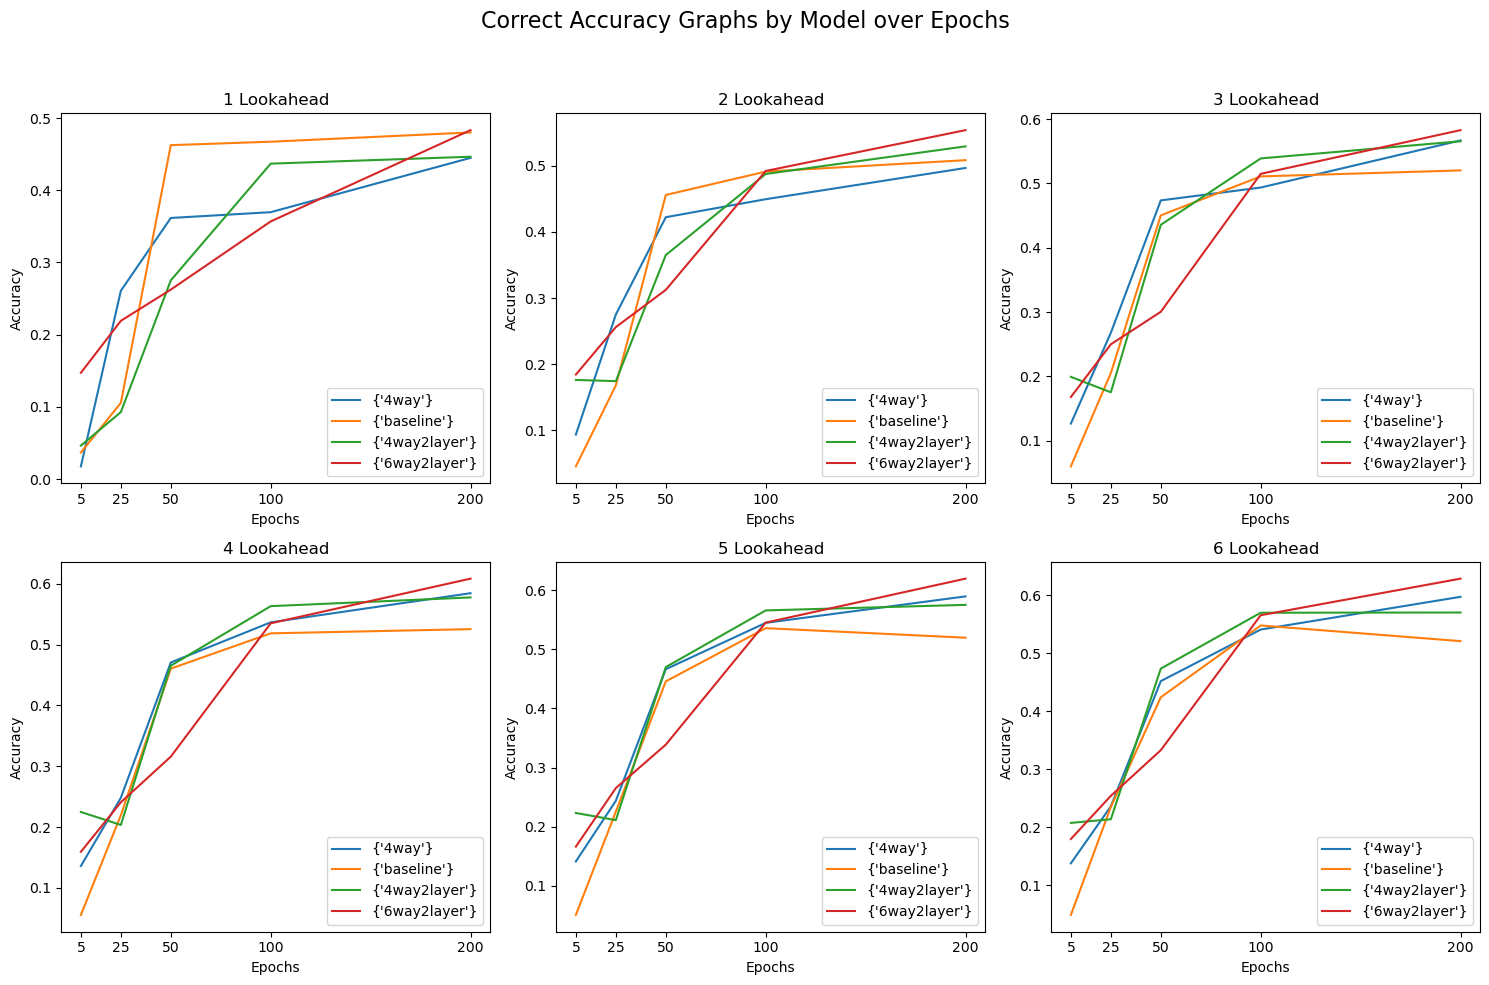

In [22]:
plot_lookahead_accuracy("correct")

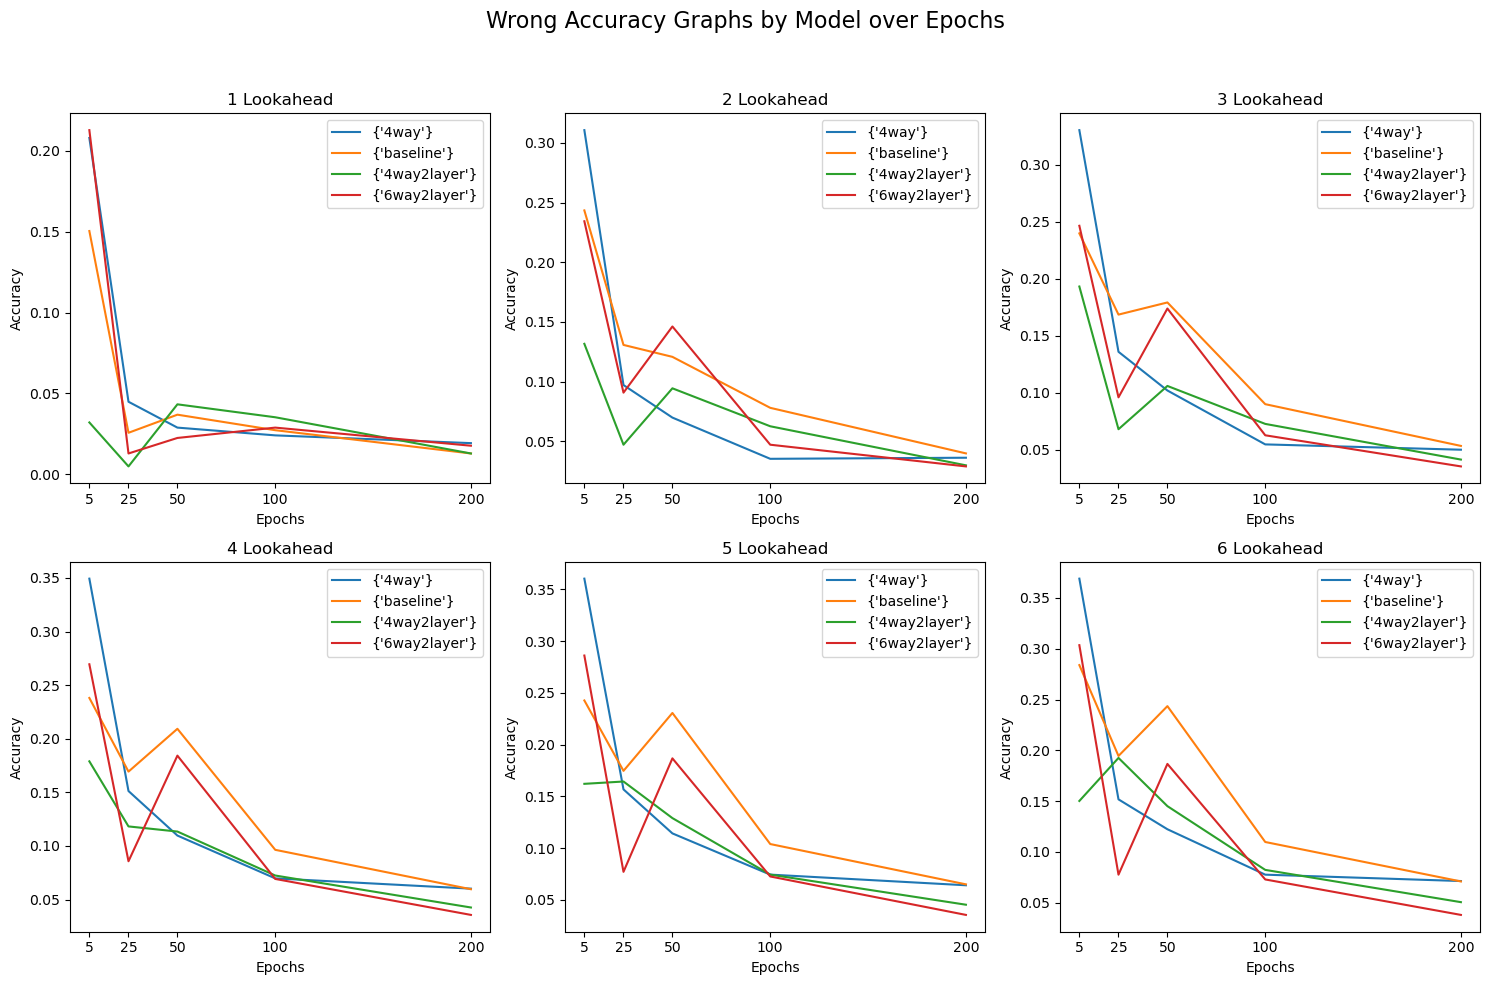

In [23]:
plot_lookahead_accuracy("wrong")

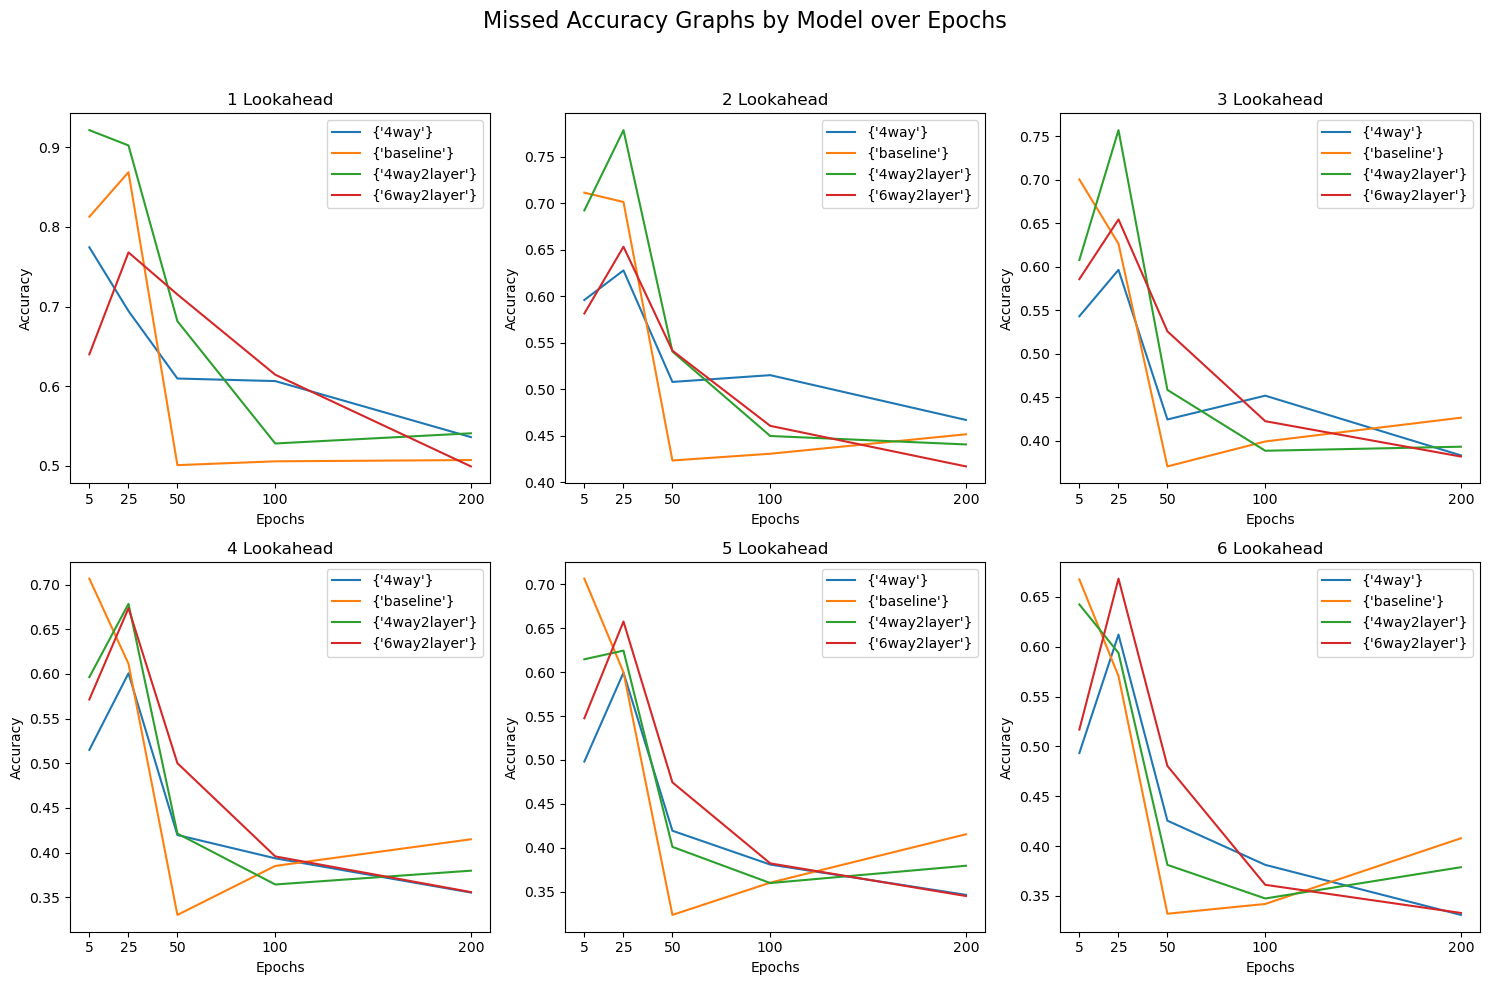

In [24]:
plot_lookahead_accuracy("missed")